In [1]:
import geopandas as gpd
import numpy as np

In [11]:
def preprocess_farm_centroid(
      farm_centroid_dir,
      gm_polygon_shp_dir,
      gm_centroid_shp_dir,
      output_preprocessed_farm_dir):

  farm_gm_id_joined = add_gm_id_farm_centroid(farm_centroid_dir, gm_polygon_shp_dir)
  gm_centroid_gm_id = add_gm_id_gm_centroid(gm_polygon_shp_dir, gm_centroid_shp_dir)
  preprocessed_farm_centroid = add_gm_name_farm_centroid(farm_gm_id_joined, gm_centroid_gm_id)

  preprocessed_farm_centroid.to_file(output_preprocessed_farm_dir, driver="ESRI Shapefile")

def add_gm_id_farm_centroid(
  farm_centroid_dir,
  gm_polygon_shp_dir,
  discard_points_outside_nl = True
):

  gm_polygon_gdf = gpd.read_file(gm_polygon_shp_dir)
  farm_centroid_gdf = gpd.read_file(farm_centroid_dir)

  # Initialize the gemeente id column with -111
  farm_centroid_gdf["gm_id"] = -111

  # Spatial join to match grid points with gemeente geometries
  farm_gm_polygon_joined = gpd.sjoin(left_df= farm_centroid_gdf, right_df=gm_polygon_gdf[["OBJECTID", "geometry"]], how="left", predicate="within")
 
  # Assign the gemeente_id from the join result
  farm_centroid_gdf["gm_id"] =  farm_gm_polygon_joined["OBJECTID"]

  # Filter points outside the NL region if required
  if discard_points_outside_nl:
      farm_centroid_gdf =  farm_centroid_gdf[farm_centroid_gdf["gm_id"].notna()]
      # Convert to integer type if no missing values are expected
      farm_centroid_gdf["gm_id"] = farm_centroid_gdf["gm_id"].astype(int)

  # Returning the farm_centroid_gdf with gm_id
  return(farm_centroid_gdf)


def add_gm_id_gm_centroid(
  gm_polygon_shp_dir,
  gm_centroid_shp_dir
):

  # Loading the files
  gm_polygon_gdf = gpd.read_file(gm_polygon_shp_dir)
  gm_centroid_gdf = gpd.read_file(gm_centroid_shp_dir)

  # Initializing the gm_id column with -111
  gm_centroid_gdf["gm_id"] = -111

  # Spatial joining the two 
  gm_centroid_polygon_joined = gpd.sjoin(left_df=gm_centroid_gdf, right_df = gm_polygon_gdf, how="left", predicate="within")

  # Setting the object ID as the gm ID
  gm_centroid_gdf["gm_id"] = gm_centroid_polygon_joined["OBJECTID"]

  if gm_centroid_gdf["gm_id"].isna().any():
    print("GM centroid does not belong to a polygon")

  # Returning the gm_centroid_shp with gm_id
  return(gm_centroid_gdf)

def add_gm_name_farm_centroid(farm_gm_id_joined, gm_centroid_gm_id):
  # Joining the two gdfs keeping the farm_gm_id_joined and replacing the gm ids
  # with the name of the gm
  preprocessed_farm_centroid = farm_gm_id_joined.merge(gm_centroid_gm_id[["gm_id", "Name"]], on="gm_id", how="left")
  preprocessed_farm_centroid.drop(columns=["gm_id"], inplace=True)

  # Rename "Name" column to "gm_name"
  # preprocessed_farm_centroid.rename(columns={"Name": "gm_name"}, inplace=True)

  if preprocessed_farm_centroid["Name"].isna().any():
      print("Warning: Some farm centroids do not belong to a particular gemeente centroid.")

  return(preprocessed_farm_centroid)

In [12]:
farm_centroid_dir = "../preprocessed_data/grid_centroid.shp"
gm_polygon_shp_dir = "../gemeente_2013_corrected_shp/corrected_gemeentes_2013.shp"
gm_centroid_shp_dir = "../../Covid19_Model_Boris_Update/StartPopulationHighestR90TrMr.shp"
output_preprocessed_farm_dir =  "../preprocessed_data/preprocessed_farm.shp"

preprocess_farm_centroid(
      farm_centroid_dir,
      gm_polygon_shp_dir,
      gm_centroid_shp_dir,
      output_preprocessed_farm_dir)

GM centroid does not belong to a polygon


In [13]:
gm_polygon = gpd.read_file(output_preprocessed_farm_dir)
gm_polygon

,node,Name,geometry
0,395,Sluis,POINT (1392035.976 565963.947)
1,396,Sluis,POINT (1391399.655 569395.729)
2,417,Sluis,POINT (1393344.756 564431.652)
3,418,Sluis,POINT (1392708.534 567863.542)
4,419,Sluis,POINT (1392072.069 571295.356)
...,...,...,...
10214,17798,Vlagtwedde,POINT (1616564.637 803992.361)
10215,17799,Vlagtwedde,POINT (1615906.936 807437.81)
10216,17800,Bellingwedde,POINT (1615248.973 810883.136)
10217,17804,Oldambt,POINT (1612614.506 824663.195)


In [23]:
gm_centroid = gpd.read_file(gm_centroid_shp_dir)

keyword = "Reimerswaal"
new_df = gm_centroid[gm_centroid["Name"].str.contains(keyword, case=False, na=False)]

<Axes: >

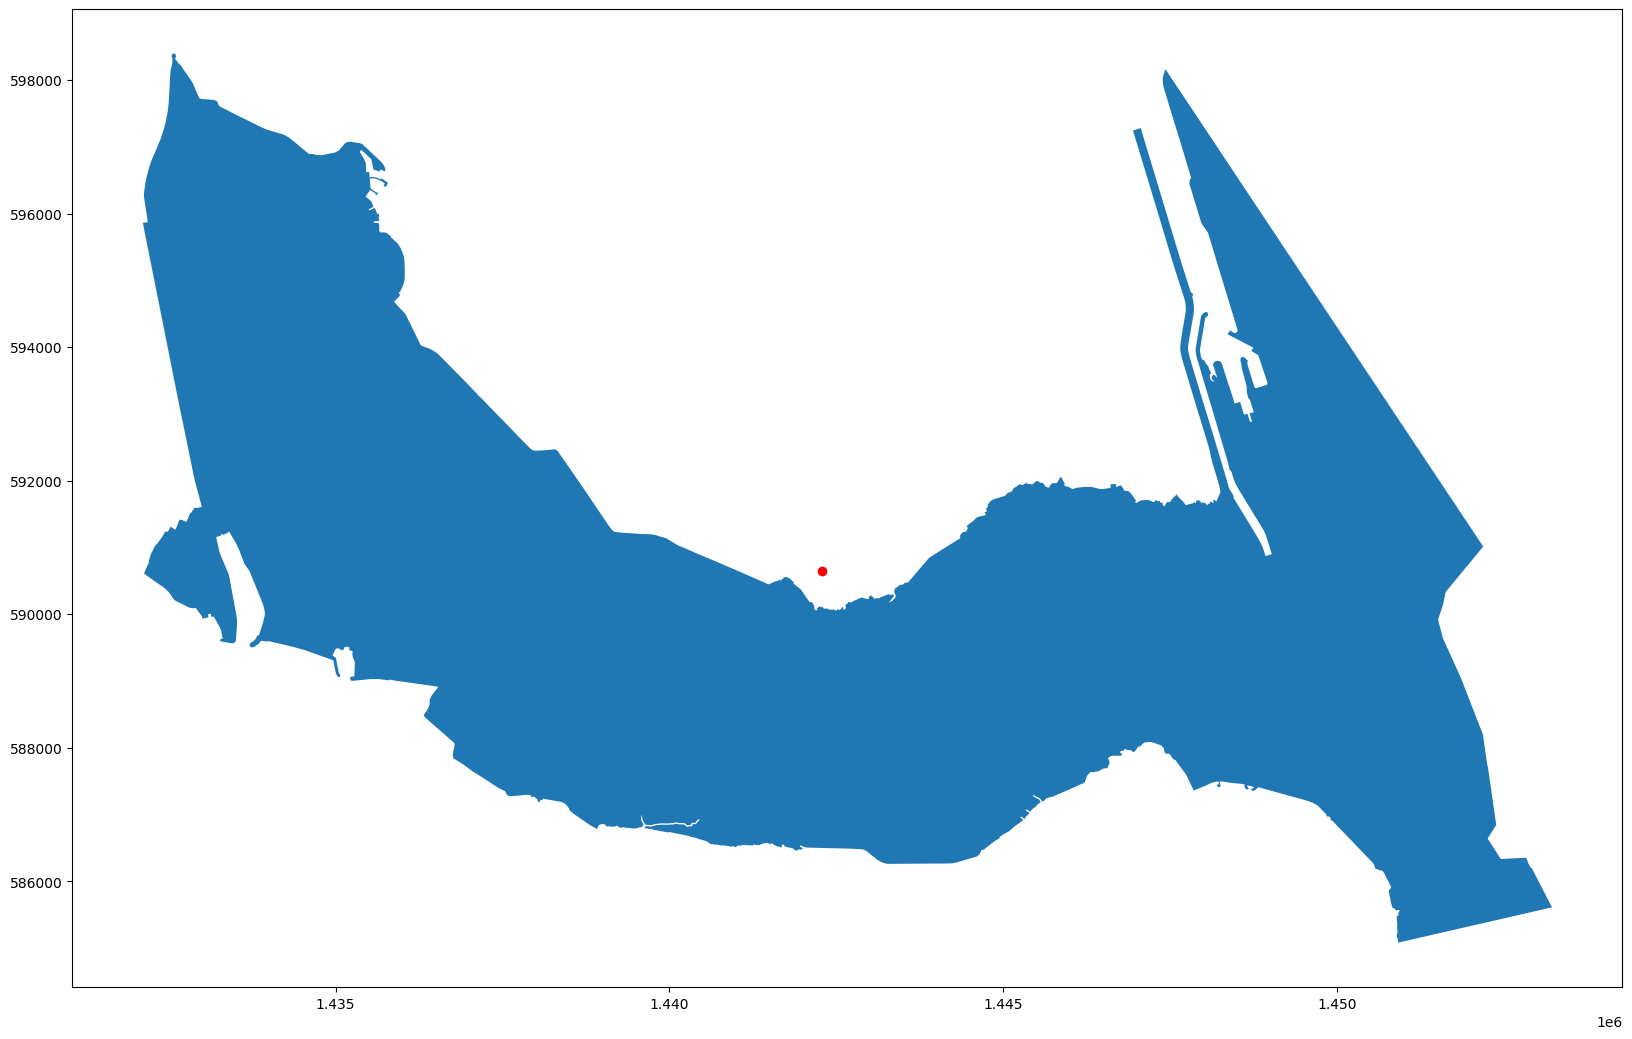

In [24]:
import matplotlib.pyplot as plt
fig_1, ax_1= plt.subplots(figsize=(20, 20))
new_df_2.plot(ax=ax_1)
new_df.plot(ax=ax_1, color = "red")